<a href="https://colab.research.google.com/github/beherapriyanka186-netizen/python_nist/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [ ]:
df=pd.read_excel("/content/drive/MyDrive/ML LAB/decision tree problem.xlsx")
print(df.head())

   Day wheather Temprature Humidity    wind Play
0    1    sunny        Hot     High    weak   No
1    2   cloudy        Hot     High    weak  Yes
2    3    sunny       mild   Normal  strong  Yes
3    4   cloudy       mild     High  strong  Yes
4    5    rainy       mild     High  strong   No


In [ ]:
import numpy as np
import math

def entropy(target):
    values, counts = np.unique(target,return_counts=True)
    entropy_value = 0
    for count in counts:

        probability = count / len(target)

        entropy_value -= probability * math.log2(probability)

    return entropy_value
result = entropy(df["Play"])

print("Entropy of Play =", round(result, 4))

Entropy of Play = 1.0


In [ ]:
def entropy(target):
    values, counts = np.unique(target, return_counts=True)
    entropy_value = 0
    for count in counts:
        probability = count / len(target)
        entropy_value -= probability * math.log2(probability)
    return entropy_value

def information_gain(df, feature, target):
    parent_entropy = entropy(df[target])
    values, counts = np.unique(df[feature], return_counts=True)
    weighted_entropy = 0

    for value, count in zip(values, counts):
        subset = df[df[feature] == value]
        weighted_entropy += (count / len(df)) * entropy(subset[target])

    return parent_entropy - weighted_entropy


features = ["wheather", "Temprature", "Humidity", "wind"]

for feature in features:
    gain = information_gain(df, feature, "Play")
    print(feature,"Information Gain =",round(gain, 4))

wheather Information Gain = 0.4
Temprature Information Gain = 0.1145
Humidity Information Gain = 0.1103
wind Information Gain = 0.1245


In [ ]:
def best_feature(df, features, target):

    gains = {}

    for feature in features:

        gains[feature] = information_gain(
            df,
            feature,
            target
        )

    best = max(
        gains,
        key=gains.get
    )

    return best, gains


best, gains = best_feature(
    df,
    features,
    "Play"
)

print("Best Feature =", best)
print("Gains =", gains)

Best Feature = wheather
Gains = {'wheather': np.float64(0.4), 'Temprature': np.float64(0.11452470277266569), 'Humidity': np.float64(0.11034030477602386), 'wind': np.float64(0.12451124978365313)}


In [ ]:
def ID3(df, features, target):
    if len(np.unique(df[target])) == 1:

        return df[target].iloc[0]
    if len(features) == 0:

        return df[target].mode()[0]

    best, gains = best_feature(
        df,
        features,
        target
    )

    tree = {
        best: {}
    }

    remaining_features = [
        feature
        for feature in features
        if feature != best]
    for value in df[best].unique():
        subset = df[df[best] == value]
        if len(subset) == 0:
          tree[best][value] = df[target].mode()[0]

        else:
            tree[best][value] = ID3(subset,remaining_features,target)
    return tree
tree = ID3(df,features,"Play")
print(tree)



{'wheather': {'sunny': {'Temprature': {'Hot': 'No', 'mild': 'Yes'}}, 'cloudy': 'Yes', 'rainy': {'wind': {'strong': 'No', 'weak': 'Yes'}}}}


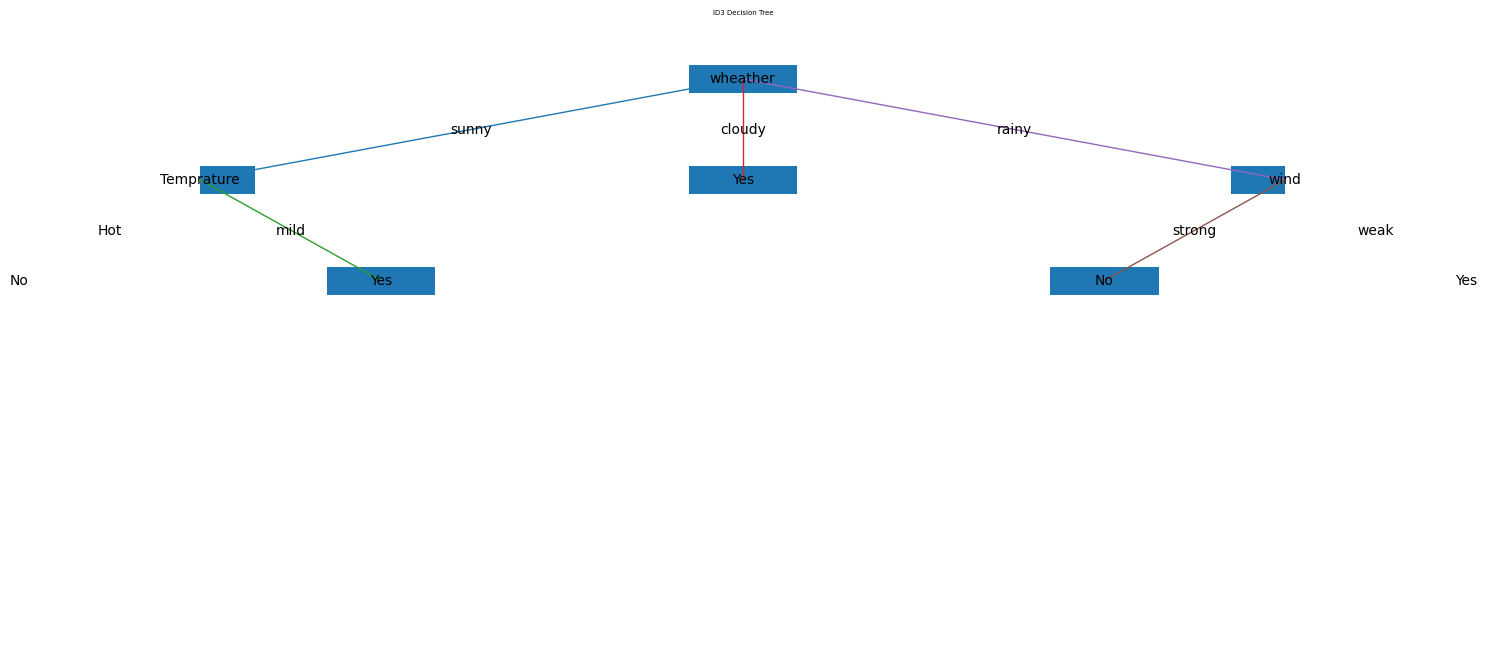

In [ ]:
from matplotlib.patches import Rectangle
def get_positions(tree, x=0.5, y=1.0, width=1.0, level=0,
                  positions=None, edges=None):

    if positions is None:
        positions = {}

    if edges is None:
        edges = []

    # Leaf node
    if not isinstance(tree, dict):
        return positions, edges

    feature = list(tree.keys())[0]

    branches = tree[feature]
    positions[id(tree)] = (x, y, feature)

    n = len(branches)
    child_x_positions = np.linspace(
        x - width / 2,
        x + width / 2,
        n
    )

    for child_x, (value, subtree) in zip(
        child_x_positions,
        branches.items()
    ):

        if isinstance(subtree, dict):

            child_feature = list(subtree.keys())[0]

            positions[id(subtree)] = (
                child_x,
                y - 0.18,
                child_feature
            )

            edges.append(
                (
                    x,
                    y,
                    child_x,
                    y - 0.18,
                    value
                )
            )

            get_positions(subtree,child_x,y - 0.18,width / n,level + 1,positions,edges)

        else:

            positions[("leaf", child_x, y - 0.18, value)] = (child_x,y - 0.18,str(subtree) )
            edges.append(
                (
                    x,
                    y,
                    child_x,
                    y - 0.18,
                    value
                )
            )

    return positions, edges
def plot_id3_tree(tree):

    fig, ax = plt.subplots(figsize=(14, 8))

    positions, edges = get_positions(tree)

    for x1, y1, x2, y2, label in edges:

        ax.plot(
            [x1, x2],
            [y1, y2],
            linewidth=1
        )

        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            str(label),
            ha="center",
            va="center",
            fontsize=10
        )

    for key, (x, y, label) in positions.items():

        ax.add_patch(
            Rectangle(
                (x - 0.05, y - 0.025),
                0.10,
                0.05,
                fill=True
            )
        )

        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=10
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.1)

    ax.axis("off")

    plt.title("ID3 Decision Tree",
        fontsize=5)

    plt.show()
plot_id3_tree(tree)

In [ ]:
def gini_impurity(target):

    values, counts = np.unique(
        target,
        return_counts=True
    )

    probabilities = counts / len(target)

    gini = 1 - np.sum(probabilities ** 2)

    return gini
    result = gini_impurity(df["Play"])

print("Gini Impurity of Play =", round(result, 4))

Gini Impurity of Play = 1.0


In [ ]:
import numpy as np
df=pd.read_excel("/content/drive/MyDrive/ML LAB/decision tree problem.xlsx")
def gini_index(df, feature, target):

    total_gini = 0

    values, counts = np.unique(
        df[feature],
        return_counts=True
    )

    for value, count in zip(values, counts):

        subset = df[df[feature] == value]

        gini = gini_impurity(
            subset[target]
        )

        weight = count / len(df)

        total_gini += weight * gini

    return total_gini
features = ["wheather","Temprature","Humidity","wind"]
for feature in features:

    gini = gini_index(df,feature,"Play")

    print(feature,"=",round(gini, 4))

wheather = 0.2833
Temprature = 0.44
Humidity = 0.4429
wind = 0.4167


  Q.2 decision tree of Diabetes Dataset

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Accuracy: 0.7467532467532467
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        99
           1       0.63      0.71      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
we

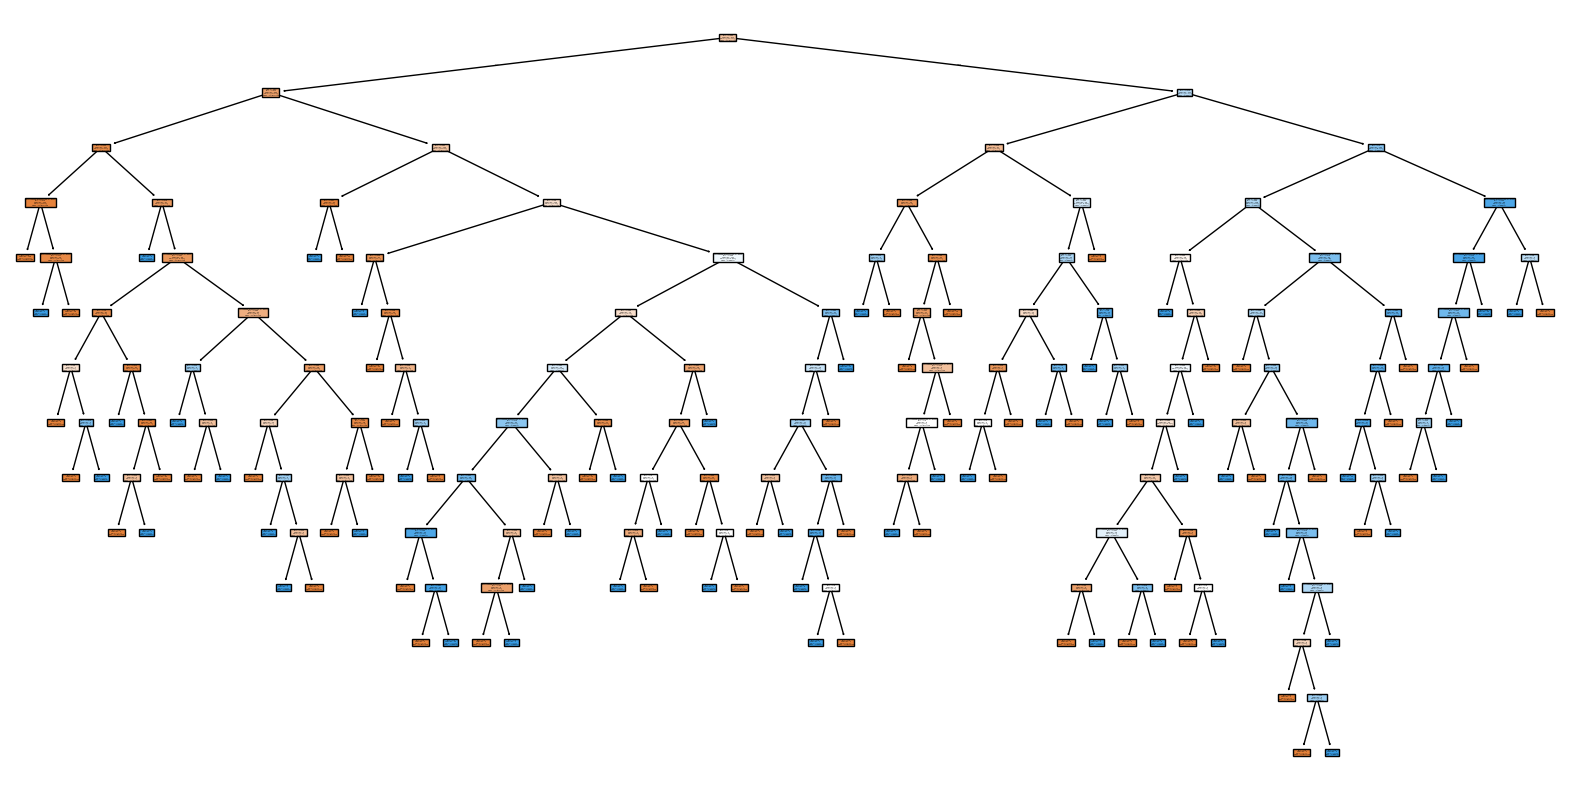

                    Feature  Importance
1                   Glucose    0.307515
5                       BMI    0.180046
2             BloodPressure    0.134288
6  DiabetesPedigreeFunction    0.100775
7                       Age    0.098552
0               Pregnancies    0.069463
4                   Insulin    0.068889
3             SkinThickness    0.040474


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/ML LAB/diabetes.csv")

# Display dataset
print(df.head())

# Separate features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create Decision Tree model
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=0
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print(classification_report(y_test, y_pred))
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True
)

plt.show()
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(importance.sort_values(
    by="Importance",
    ascending=False
))